# Import Data


In [1]:
from datastream.utils import *
import pandas as pd
from datastream.ff_data import *

# ── 1. import ──────────────────────────────────────────────────────────────
df = pd.read_feather(
    "D:\\Datastream\\PriceData\\US\\processed\\US_data_panel_filtered_0.25.feather"
)

# ── 2. monthly returns ─────────────────────────────────────────────────────
# determine_monthly_returns now keeps the first (NaN-return) row per stock,
# which carries the MarketCAP needed as t-1 weight in the first portfolio month.
monthly_returns = (
    df.groupby("Stock", group_keys=True)[["Date", "ReturnIndex", "MarketCAP"]]
    .apply(lambda x: determine_monthly_returns(
        x, price_column="ReturnIndex", date_column="Date"
    ))
    .reset_index()
    .sort_values(["Date", "Stock"])
    .dropna(subset=["MonthlyReturn"])   # drop the first obs per stock (NaN return)
    .reset_index(drop=True)
)

# ── 3. portfolios ──────────────────────────────────────────────────────────
# Both functions lag MarketCAP internally and share the same eligible universe.
ew_pf = equally_weighted_portfolio(
    monthly_returns, "MonthlyReturn", "MarketCAP", "Stock", "Date"
)
vw_pf = value_weighted_portfolio(
    monthly_returns, "MonthlyReturn", "MarketCAP", "Stock", "Date"
)

# ── 4. align on a common Period index ─────────────────────────────────────
def to_period_index(df, date_col, col_rename, period="M"):
    return (
        df.set_index(pd.PeriodIndex(df[date_col].dt.to_period(period)))
        .drop(columns=date_col)
        .rename(columns={"PortfolioReturn": col_rename})
    )

ew = to_period_index(ew_pf, "Date", "EW_PF")
vw = to_period_index(vw_pf, "Date", "MV_PF")
pf = ew.join(vw)

# ── warm the cache (run once per session, or on notebook startup) ──────────
# Downloads anything missing; prompts once if any entry is > 90 days old.
prefetch_ff_cache()

# ── then use exactly as before ─────────────────────────────────────────────
ff3m = get_ff_factors(3, "monthly")

Skipped. Using existing cache where available.
Cache miss or stale for FF3 monthly — downloading... done (1,202 rows).


# Descriptive Comparison to Fama-French Market Value Portfolio

In [2]:
compare_to_mkt = pd.merge(pf, (ff3m["Mkt-RF"] + ff3m["RF"]).to_frame("Mkt"), left_index = True, right_index = True)
compare_to_mkt.describe()

,EW_PF,MV_PF,Mkt
count,385.000000,385.000000,385.000000
mean,0.010411,0.009487,0.009615
std,0.049622,0.043957,0.044456
min,-0.223444,-0.174170,-0.171200
25%,-0.016072,-0.017037,-0.017500
50%,0.014171,0.015379,0.015300
75%,0.040525,0.036319,0.037700
max,0.179553,0.131750,0.136000


In [3]:
compare_to_mkt.corr()

,EW_PF,MV_PF,Mkt
EW_PF,1.000000,0.905883,0.906220
MV_PF,0.905883,1.000000,0.999139
Mkt,0.906220,0.999139,1.000000


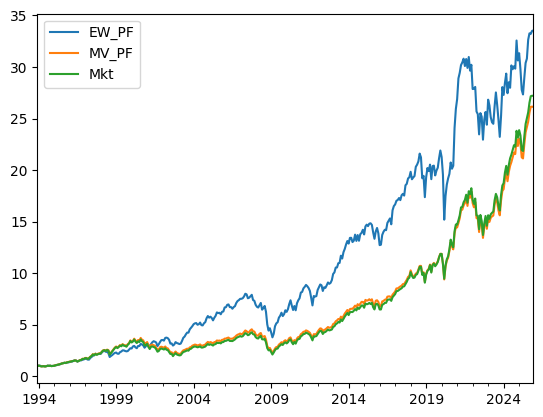

In [4]:
cumulative_return_plot = (1 + compare_to_mkt).cumprod().plot()

# Fama-French Regression

In [5]:
import statsmodels.api as sm

regression_data = pd.merge(pf, ff3m, left_index = True, right_index = True)
X = regression_data.loc[:, ["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X)

y_ew = regression_data["EW_PF"] - regression_data["RF"]
y_mv = regression_data["MV_PF"] - regression_data["RF"]

results_ew = sm.OLS(y_ew, X).fit()
results_mv = sm.OLS(y_mv, X).fit()

print(results_mv.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 8.501e+04
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:59:13   Log-Likelihood:                 1910.0
No. Observations:                 385   AIC:                            -3812.
Df Residuals:                     381   BIC:                            -3796.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.173e-05   8.83e-05     -0.812      0.4

In [6]:
print(results_ew.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     3836.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          3.45e-284
Time:                        14:59:18   Log-Likelihood:                 1272.4
No. Observations:                 385   AIC:                            -2537.
Df Residuals:                     381   BIC:                            -2521.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      1.708      0.0